# Patient Visit Pattern Analysis
**ASA DataFest 2026 — Stormont Vail Health**

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.facecolor': 'white'})

BLUE = '#378ADD'
RED  = '#E24B4A'
GREY = '#94A3B8'
print('Setup complete')


Setup complete


## 1. Load Data

In [2]:
diag  = pd.read_csv('../data/diagnosis.csv')
enct  = pd.read_csv('../data/encounters.csv')
pat   = pd.read_csv('../data/patients.csv')

print(f'encounters: {enct.shape}, patients: {pat.shape}, diagnoses: {diag.shape}')


encounters: (7675801, 31), patients: (947685, 12), diagnoses: (1531262, 5)


## 2. Feature Engineering

In [3]:
# Age groups
def assign_age_group(year):
    if year >= 2024: return 'Early Stage'
    if year >= 2014: return 'Children'
    if year >= 2006: return 'Adolescence'
    if year >= 1987: return 'Early Adulthood (21-39)'
    if year >= 1960: return '40-64'
    return '65+'

pat['age_group']   = pat['PatientBirthYearBin'].apply(assign_age_group)
pat['county_fips'] = pat['CensusBlockGroupFipsCode'].astype(str).str[:6]

# Admit datetime
enct['admit_dt'] = pd.to_datetime(
    enct[['AdmitYear','AdmitMonth','AdmitDay','AdmitHour','AdmitMinute']]
    .rename(columns={'AdmitYear':'year','AdmitMonth':'month','AdmitDay':'day',
                     'AdmitHour':'hour','AdmitMinute':'minute'}),
    errors='coerce'
)

# Visit counts per patient
visit_counts = (enct.groupby('PatientDurableKey')
                .size().reset_index(name='total_encounters'))
visit_counts['visit_group'] = visit_counts['total_encounters'].apply(
    lambda n: 'Single Visit' if n == 1 else 'Multiple Visits'
)

# First encounter per patient
first_enc = (enct.sort_values(['PatientDurableKey','admit_dt'])
             .groupby('PatientDurableKey', as_index=False).first())

# ICD-10 chapter (first character)
diag_unique = diag[['DiagnosisKey','GroupCode']].drop_duplicates()
diag_unique['first_char'] = (diag_unique['GroupCode']
    .str.replace(r'^ICD-10-CM: ', '', regex=True)
    .str[0])

# Master modeling dataset
conversion = (
    first_enc
    .merge(visit_counts,  on='PatientDurableKey', how='left')
    .merge(pat,           left_on='PatientDurableKey', right_on='DurableKey', how='left')
    .merge(diag_unique,   left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='left')
    .dropna(subset=['age_group','first_char','AdmissionType','VisitType',
                    'county_fips','visit_group'])
)

print(f'Modeling dataset: {conversion.shape}')
print(conversion['visit_group'].value_counts())


Modeling dataset: (332269, 51)
visit_group
Multiple Visits    288894
Single Visit        43375
Name: count, dtype: int64


## 3. Visit Frequency Overview

In [4]:
freq = (enct.groupby('PatientDurableKey').size()
        .value_counts().sort_index().reset_index())
freq.columns = ['Encounters', 'Patients']
freq['%'] = (freq['Patients'] / freq['Patients'].sum() * 100).round(1)
print(freq.head(15).to_string(index=False))


 Encounters  Patients    %
          1     52380 14.6
          2     34635  9.6
          3     24781  6.9
          4     19110  5.3
          5     15751  4.4
          6     13378  3.7
          7     11737  3.3
          8     10378  2.9
          9      9420  2.6
         10      8592  2.4
         11      7805  2.2
         12      7145  2.0
         13      6560  1.8
         14      6275  1.7
         15      5821  1.6


## 4. Age Distribution by Visit Frequency

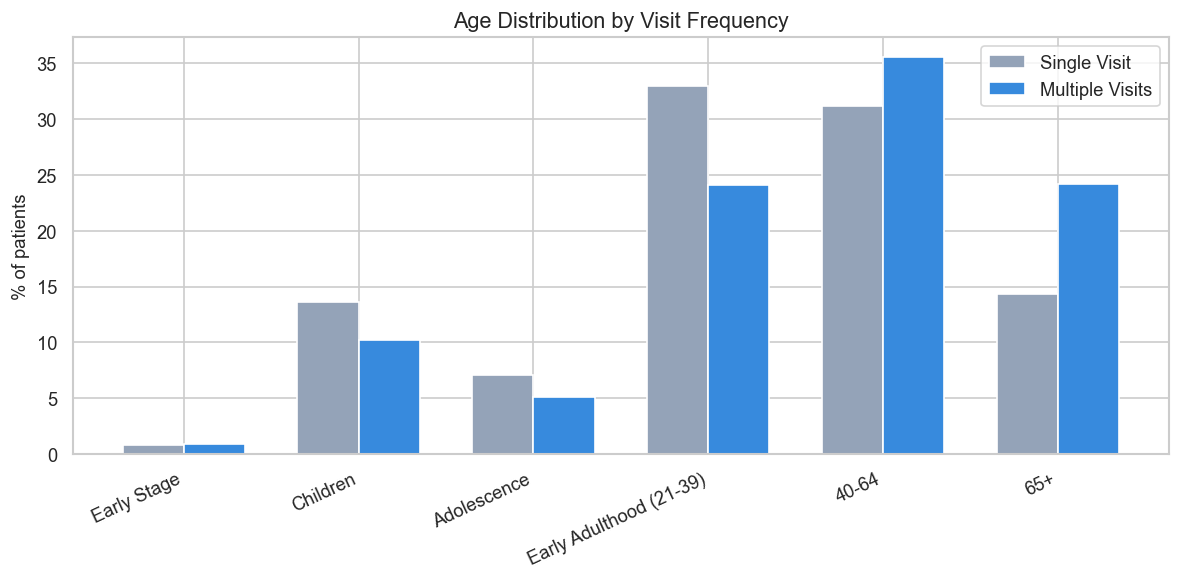

In [5]:
age_order = ['Early Stage','Children','Adolescence',
             'Early Adulthood (21-39)','40-64','65+']

age_df = (
    conversion.groupby(['visit_group','age_group'])
    .size().reset_index(name='n')
    .assign(pct=lambda d: d.groupby('visit_group')['n']
            .transform(lambda x: x / x.sum() * 100))
)
age_df['age_group'] = pd.Categorical(age_df['age_group'], categories=age_order, ordered=True)
age_df = age_df.sort_values('age_group')

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Single Visit': GREY, 'Multiple Visits': BLUE}
x = np.arange(len(age_order))
w = 0.35
for i, (vg, color) in enumerate(colors.items()):
    vals = [age_df[(age_df.visit_group==vg) & (age_df.age_group==ag)]['pct'].values
            for ag in age_order]
    vals = [v[0] if len(v) else 0 for v in vals]
    ax.bar(x + (i-0.5)*w, vals, w, label=vg, color=color)
ax.set_xticks(x)
ax.set_xticklabels(age_order, rotation=25, ha='right')
ax.set(ylabel='% of patients', title='Age Distribution by Visit Frequency')
ax.legend()
plt.tight_layout(); plt.show()


## 5. Diagnosis Category Distribution

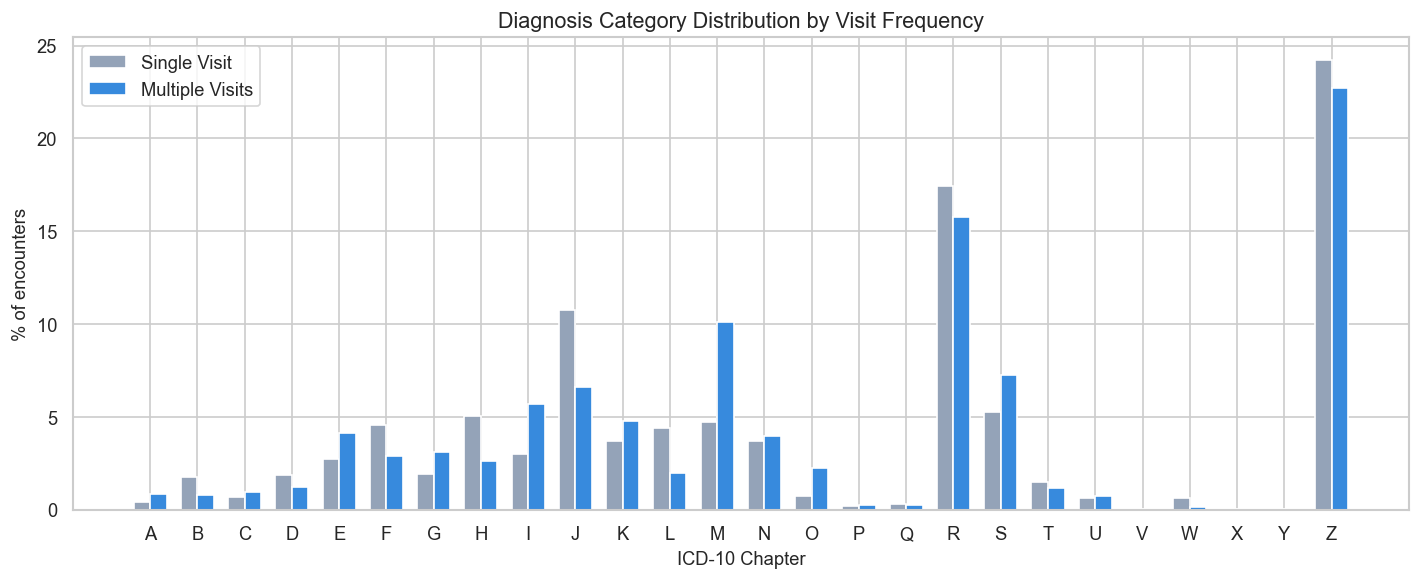

In [6]:
diag_df = (
    conversion.groupby(['visit_group','first_char'])
    .size().reset_index(name='n')
    .assign(pct=lambda d: d.groupby('visit_group')['n']
            .transform(lambda x: x / x.sum() * 100))
)

fig, ax = plt.subplots(figsize=(12, 5))
chars = sorted(conversion['first_char'].dropna().unique())
x = np.arange(len(chars))
for i, (vg, color) in enumerate(colors.items()):
    vals = [diag_df[(diag_df.visit_group==vg) & (diag_df.first_char==c)]['pct'].values
            for c in chars]
    vals = [v[0] if len(v) else 0 for v in vals]
    ax.bar(x + (i-0.5)*w, vals, w, label=vg, color=color)
ax.set_xticks(x)
ax.set_xticklabels(chars)
ax.set(xlabel='ICD-10 Chapter', ylabel='% of encounters',
       title='Diagnosis Category Distribution by Visit Frequency')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Return Risk Heatmap

Which age-diagnosis combinations most often produce multiple-visit patients?

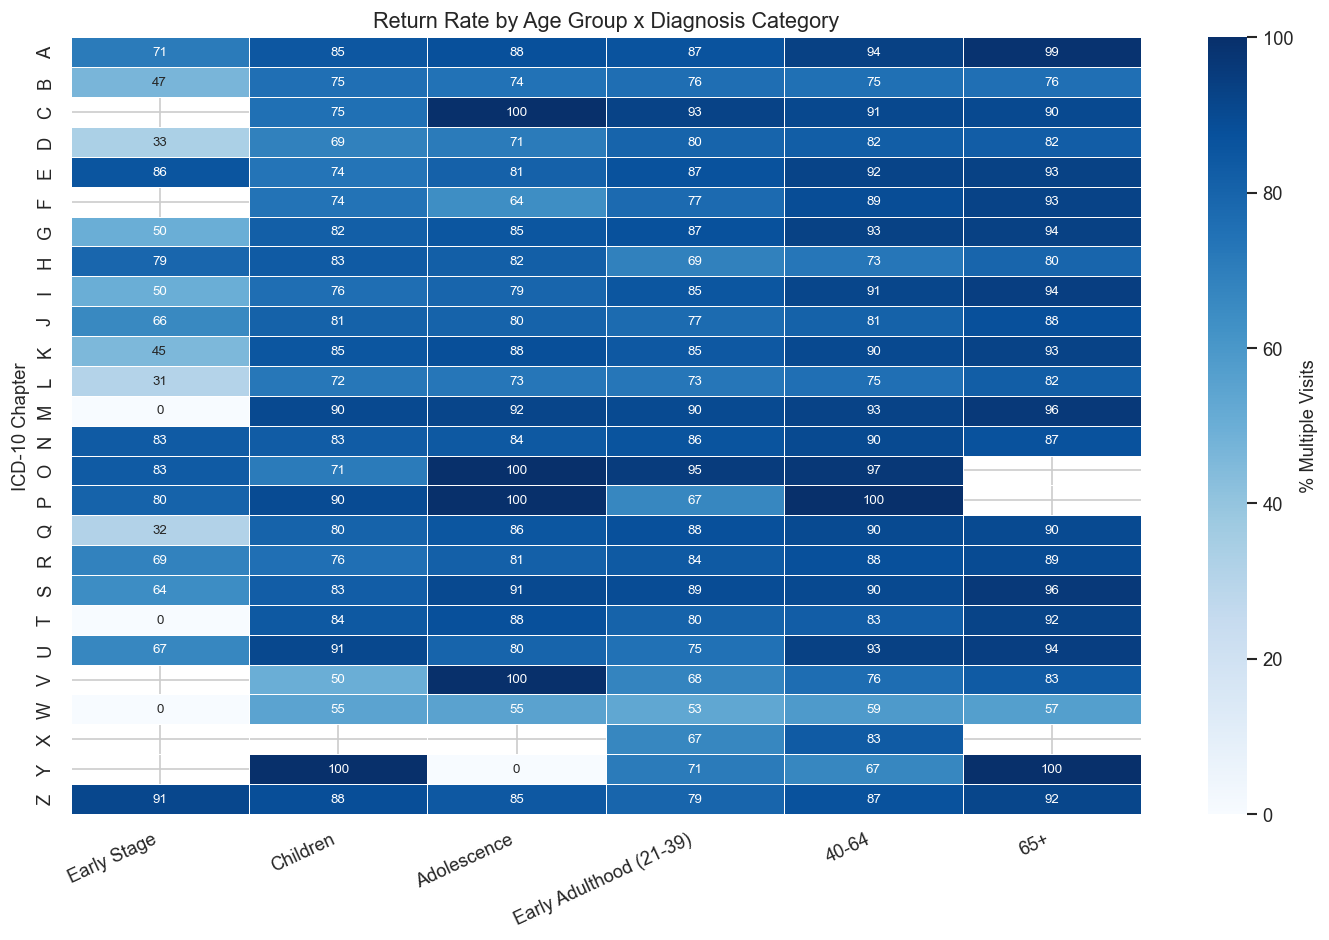

In [7]:
heatmap_df = (
    conversion.groupby(['age_group','first_char'])
    .apply(lambda d: (d['visit_group'] == 'Multiple Visits').mean() * 100)
    .reset_index(name='pct_multi')
)

pivot = heatmap_df.pivot(index='first_char', columns='age_group', values='pct_multi')
# Reorder columns
pivot = pivot[[c for c in age_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.5, annot=True, fmt='.0f',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'label': '% Multiple Visits'})
ax.set(title='Return Rate by Age Group x Diagnosis Category',
       xlabel=None, ylabel='ICD-10 Chapter')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()


## 7. High-Volume Group Spotlight

Return rates for the largest age-diagnosis combinations (n >= 10,000).

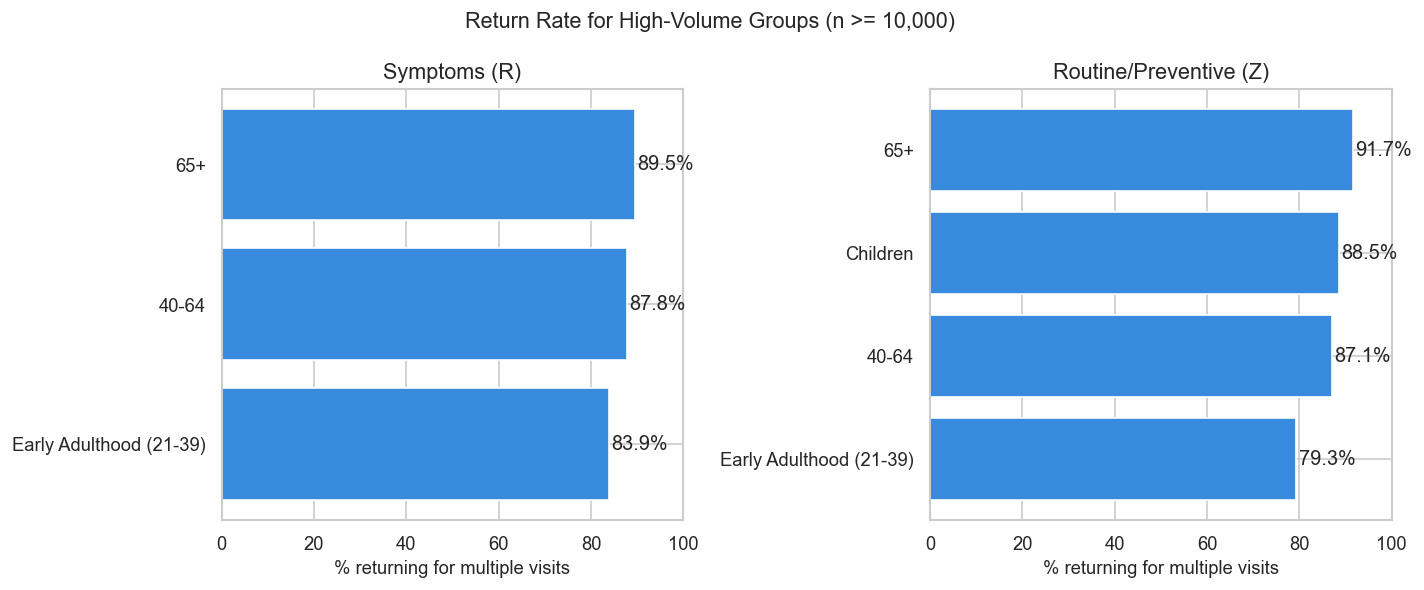

In [9]:
risk_table = (
    conversion.groupby(['age_group','first_char'])
    .apply(lambda d: pd.Series({
        'pct_multi': (d['visit_group']=='Multiple Visits').mean()*100,
        'n': len(d)
    })).reset_index()
)

significant = (
    risk_table[risk_table['n'] >= 10000]
    .query("(first_char == 'R' and age_group in ['65+','40-64','Early Adulthood (21-39)']) or "
           "(first_char == 'Z' and age_group in ['65+','40-64','Early Adulthood (21-39)','Children'])")
    .copy()
)

significant['label'] = significant['first_char'].map(
    {'R': 'Symptoms (R)', 'Z': 'Routine/Preventive (Z)'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (chapter, label) in zip(axes, [('R','Symptoms (R)'), ('Z','Routine/Preventive (Z)')]):
    sub = significant[significant['first_char'] == chapter].sort_values('pct_multi')
    ax.barh(sub['age_group'], sub['pct_multi'], color=BLUE)
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['pct_multi'] + 0.5, i, f"{row['pct_multi']:.1f}%", va='center')
    ax.set_xlim(0, 100)
    ax.set(xlabel='% returning for multiple visits', title=label)
plt.suptitle('Return Rate for High-Volume Groups (n >= 10,000)', fontsize=13)
plt.tight_layout()
plt.show()
